In [1]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
import altair as alt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from wordcloud import STOPWORDS
stopwords = set(STOPWORDS)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# reading the data
df = pd.read_csv('/Users/Downloads/webmd.csv')

# getting the shapes
print("Shape of df :", df.shape)

Shape of df : (362806, 12)


In [3]:
df.head()

,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I ...,5,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurtin...,5,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
2,65-74,Other,7/16/2012,warfarin (bulk) 100 % powder,144731,2,3,why did my PTINR go from a normal of 2.5 to ov...,3,Female,,0
3,75 or over,Other,9/23/2010,warfarin (bulk) 100 % powder,144731,2,2,FALLING AND DON'T REALISE IT,1,Female,,0
4,35-44,Other,1/6/2009,warfarin (bulk) 100 % powder,144731,1,1,My grandfather was prescribed this medication ...,1,Male,,1


In [4]:
df["Sex"].value_counts()

Female    238226
Male       98043
           26537
Name: Sex, dtype: int64

In [5]:
df['EaseofUse'].value_counts()

5     192650
4      74732
3      41303
1      35927
2      18191
6          2
10         1
Name: EaseofUse, dtype: int64

In [6]:
df['Effectiveness'].value_counts()

5     130388
4      81821
3      60406
1      59387
2      30801
6          2
10         1
Name: Effectiveness, dtype: int64

In [7]:
df['Satisfaction'].value_counts()

5     111550
1     100901
4      63158
3      51852
2      35342
6          2
10         1
Name: Satisfaction, dtype: int64

In [8]:
df.head()

,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,5,5,I'm a retired physician and of all the meds I ...,5,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,5,5,cleared me right up even with my throat hurtin...,5,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
2,65-74,Other,7/16/2012,warfarin (bulk) 100 % powder,144731,2,3,why did my PTINR go from a normal of 2.5 to ov...,3,Female,,0
3,75 or over,Other,9/23/2010,warfarin (bulk) 100 % powder,144731,2,2,FALLING AND DON'T REALISE IT,1,Female,,0
4,35-44,Other,1/6/2009,warfarin (bulk) 100 % powder,144731,1,1,My grandfather was prescribed this medication ...,1,Male,,1


In [9]:
df.isnull().any()

Age              False
Condition        False
Date             False
Drug             False
DrugId           False
EaseofUse        False
Effectiveness    False
Reviews           True
Satisfaction     False
Sex              False
Sides            False
UsefulCount      False
dtype: bool

In [10]:
df['Sex'].unique()

array(['Male', 'Female', ' '], dtype=object)

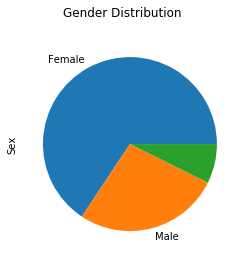

In [11]:
df = df.dropna()
ax = df.Sex.value_counts().plot.pie(subplots = True,figsize = (8,4), title = "Gender Distribution");

In [12]:
df.replace(' ', np.nan, inplace=True)
df.dropna(inplace=True)

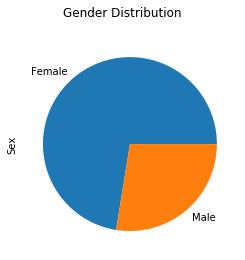

In [13]:
df = df.dropna()
ax = df.Sex.value_counts().plot.pie(subplots = True,figsize = (8,4), title = "Gender Distribution");

In [14]:
df.Sex.value_counts()

Female    202980
Male       77147
Name: Sex, dtype: int64

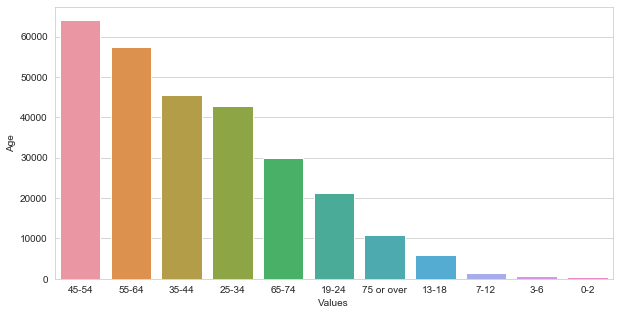

In [15]:
ageColourful = df['Age'].value_counts().reset_index()
ageColourful.columns = ["Values", "Age"]
ageColourful

# set style
sns.set_style("whitegrid");

plt.figure(figsize = (10,5));
sns.barplot(x = 'Values',y ='Age', data = ageColourful);
plt.show();

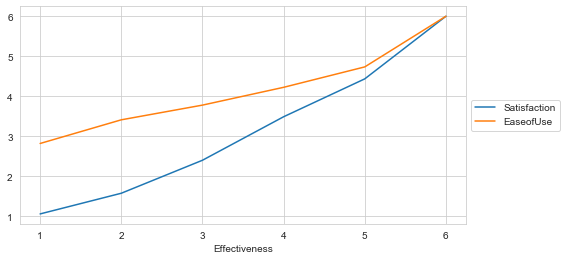

In [16]:
# line chart

df.groupby('Effectiveness')['Satisfaction','EaseofUse'].mean().plot(kind='line', figsize=(8,4))\
.legend(loc='center left', bbox_to_anchor=(1, 0.5));  # set legend

There is a very less correlation of ease-of-use to satisfaction rating as per this chart
But if we compare satisfaction rating with effectivenss rating , they are highly correlated.

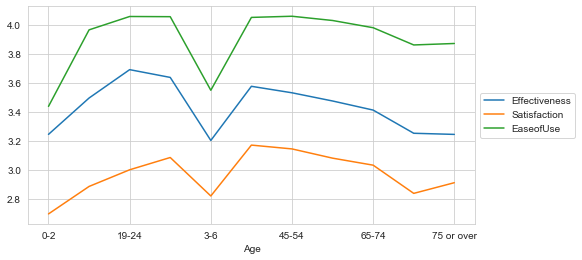

In [17]:

df.groupby('Age')['Effectiveness','Satisfaction','EaseofUse'].mean().plot(kind='line', figsize=(8,4))\
.legend(loc='center left', bbox_to_anchor=(1, 0.5));  # set legend

In [18]:
columns = ['Effectiveness','Satisfaction','EaseofUse']
df2 = df[columns]
df2corr = df2.corr()
df2corr

,Effectiveness,Satisfaction,EaseofUse
Effectiveness,1.000000,0.789414,0.524396
Satisfaction,0.789414,1.000000,0.546263
EaseofUse,0.524396,0.546263,1.000000


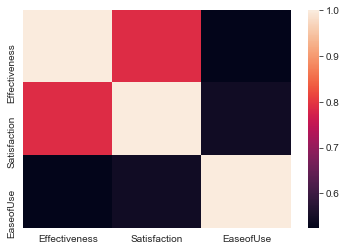

In [19]:
sns.heatmap(df2corr, xticklabels = df2corr.columns, yticklabels = df2corr.columns)

There is slight correlation between Satisfaction and Effectiveness 

# Satisfaction

In [20]:
ctab = pd.crosstab(index = df['Sex'], columns = df['Age'], values=df['Satisfaction'], aggfunc=np.mean)
ctab
# sort year in decending order
ctab.sort_index(ascending = False, inplace = True)

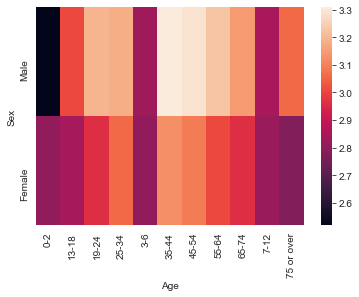

In [21]:
sns.heatmap(ctab);

Male customers in 35-44 age category have higher effectiveness rating
Whereas the opposite is true in 25-34 age category
Drug has different effects in males and females in different age groups

# Effectiveness

In [22]:
ctab = pd.crosstab(index = df['Sex'], columns = df['Age'], values=df['Effectiveness'], aggfunc=np.mean)
ctab
# sort year in decending order
ctab.sort_index(ascending = False, inplace = True)

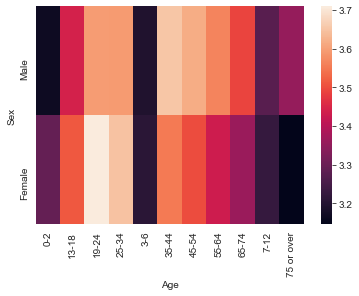

In [23]:
sns.heatmap(ctab);

Male customers in 19-24 age category have higher effectiveness rating
Whereas the opposite is true in 25-34 age category
Drug has different effects in males and females in different age groups

# EaseofUse

In [24]:
ctab = pd.crosstab(index = df['Sex'], columns = df['Age'], values=df['EaseofUse'], aggfunc=np.mean)
ctab
# sort year in decending order
ctab.sort_index(ascending = False, inplace = True)

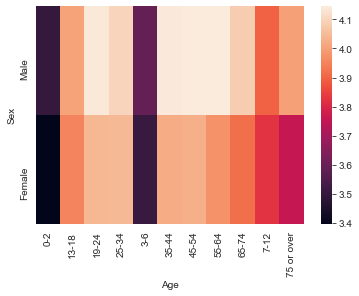

In [25]:
sns.heatmap(ctab);

Male customers in 19-24 age category have higher EaseofUse rating
Whereas the opposite is true in 25-34 age category
Drug has different effects in males and females in different age groups

In [26]:
ctab = pd.crosstab(index = df['Sex'], columns = df['Effectiveness'], values=df['Satisfaction'], aggfunc=np.mean)
ctab

Effectiveness,1,2,3,4,5,6
Sex,,,,,,
Female,1.055689,1.547115,2.360637,3.430139,4.383714,6.0
Male,1.063693,1.645064,2.496112,3.620658,4.571966,NaN


In [27]:
ctab
# sort year in decending order
ctab.sort_index(ascending = False, inplace = True)

#Classified with gender we can see how the Satisfaction Rating is with respect to Ease of Using them

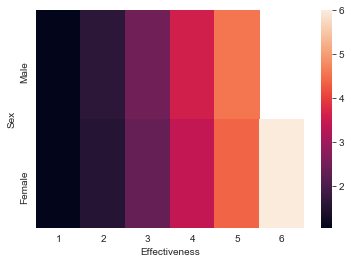

In [28]:
sns.heatmap(ctab);

In [29]:
def relabel(x):
    return 0 if x < 3 else 1 if x == 3 else 2

Satisfaction 1 and 2 → 0 (Negative)
Satisfaction 3           → 1 (Neutral)
Satisfaction 4 and 5 → 2 (Positive)

In [30]:
df["Satisfaction"] = df["Satisfaction"].apply(relabel)

Effectiveness 1 and 2 → 0 (Negative)
Effectiveness 3           → 1 (Neutral)
Effectiveness 4 and 5 → 2 (Positive)

In [31]:
df["Effectiveness"] = df["Effectiveness"].apply(relabel)

EaseofUse 1 and 2 → 0 (Negative)
EaseofUse 3           → 1 (Neutral)
EaseofUse 4 and 5 → 2 (Positive)

In [32]:
df["EaseofUse"] = df["EaseofUse"].apply(relabel)

In [33]:
df

,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,2,2,I'm a retired physician and of all the meds I ...,2,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,2,2,cleared me right up even with my throat hurtin...,2,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
6,25-34,Birth Control,6/15/2017,wymzya fe,163180,2,2,Haven't gotten pregnant so it does it's job. I...,0,Female,"Nausea , vomiting , headache , bloating , ...",0
7,45-54,Disease of Ovaries with Cysts,1/30/2017,wymzya fe,163180,2,2,I have take this for 5 years age 45-50 to prev...,2,Female,"Nausea , vomiting , headache , bloating , ...",0
9,55-64,Stuffy Nose,10/29/2012,"12 hour nasal relief spray, non-aerosol",9800,2,0,The 12 hour spray only works for me for 6 hours.,0,Male,"Temporary burning, stinging, dryness in the no...",0
...,...,...,...,...,...,...,...,...,...,...,...,...
362799,25-34,Stop Smoking,11/16/2008,chantix,144470,0,2,I have tried the patch and quitting cold turke...,2,Female,"Nausea , headache , vomiting , drowsiness, g...",5
362801,55-64,Stop Smoking,11/14/2008,chantix,144470,2,2,I took the whole 12 weeks.I could have stopped...,2,Female,"Nausea , headache , vomiting , drowsiness, g...",2
362803,25-34,Stop Smoking,11/13/2008,chantix,144470,0,2,"As long as I was on chantix, I didn't smoke. ...",0,Female,"Nausea , headache , vomiting , drowsiness, g...",3
362804,55-64,Stop Smoking,11/13/2008,chantix,144470,2,2,Started this medication Oct 5th 2008. Haven't ...,2,Male,"Nausea , headache , vomiting , drowsiness, g...",1


In [34]:
df.describe()

,DrugId,EaseofUse,Effectiveness,Satisfaction,UsefulCount
count,280127.000000,280127.000000,280127.000000,280127.000000,280127.000000
mean,35901.410446,1.592674,1.333227,1.076729,7.369996
std,51648.629375,0.733578,0.853051,0.924699,9.449793
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4896.000000,1.000000,0.000000,0.000000,1.000000
50%,9548.000000,2.000000,2.000000,1.000000,4.000000
75%,63163.000000,2.000000,2.000000,2.000000,10.000000
max,178485.000000,2.000000,2.000000,2.000000,255.000000


In [35]:
for col in ["Age", "Condition", "Sex", "Reviews"]:
    df = df[(df[col].astype(bool) & df[col].notnull())]

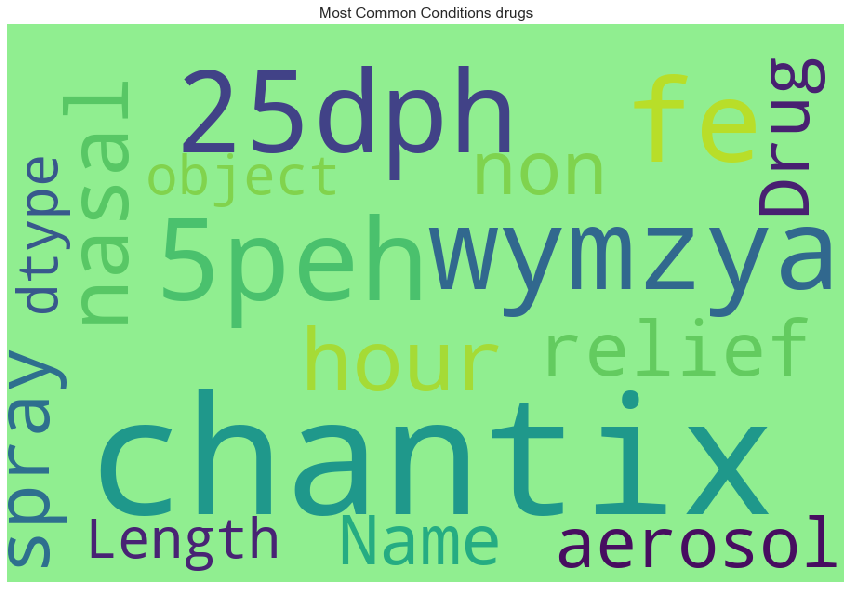

In [36]:
# most common drugs

wordcloud = WordCloud(background_color = 'lightgreen', stopwords = stopwords, max_words = 100, width = 900, height = 600).generate(str(df['Drug']))

plt.rcParams['figure.figsize'] = (15, 15)
plt.title('Most Common Conditions drugs', fontsize = 15)
print(wordcloud)
plt.axis('off')
plt.imshow(wordcloud)
plt.show()

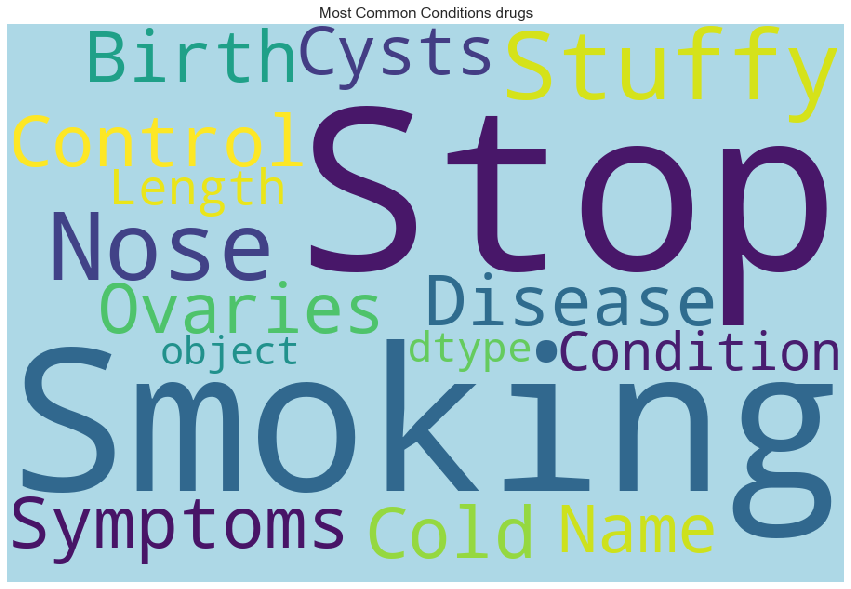

In [37]:
# most common condition

wordcloud = WordCloud(background_color = 'lightblue', stopwords = stopwords, max_words = 100, width = 900, height = 600).generate(str(df['Condition']))

plt.rcParams['figure.figsize'] = (15, 15)
plt.title('Most Common Conditions drugs', fontsize = 15)
print(wordcloud)
plt.axis('off')
plt.imshow(wordcloud)
plt.show()

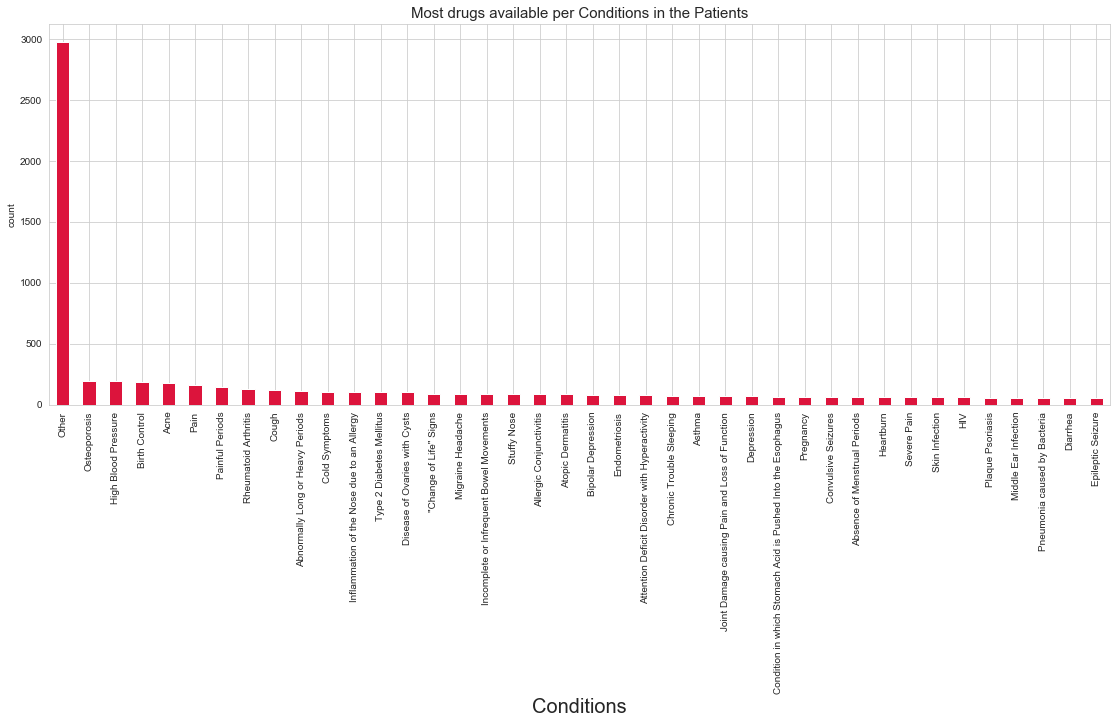

In [38]:
# checking the most popular drugs per conditions

df.groupby(['Condition'])['Drug'].nunique().sort_values(ascending = False).head(40).plot.bar(figsize = (19, 7), color = 'crimson')
plt.title('Most drugs available per Conditions in the Patients', fontsize = 15)
plt.xlabel('Conditions', fontsize = 20)
plt.ylabel('count')
plt.show()

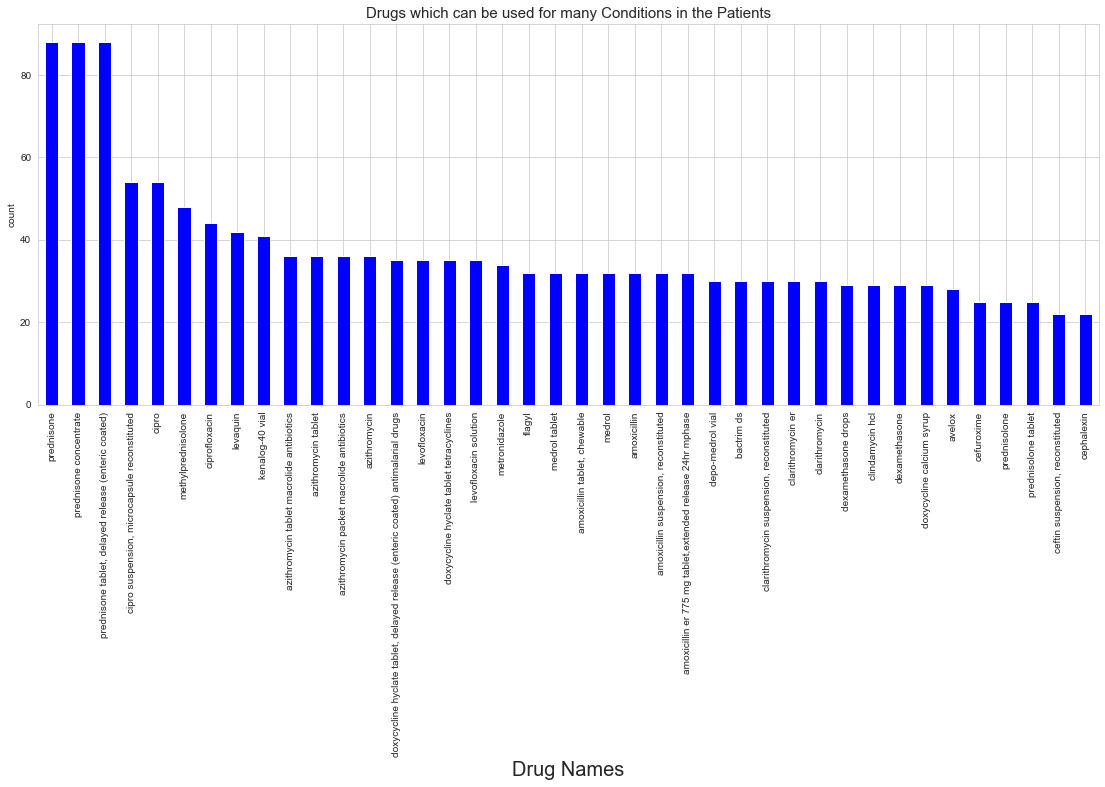

In [39]:
# checking the most popular conditions per drugs

df.groupby(['Drug'])['Condition'].nunique().sort_values(ascending = False).head(40).plot.bar(figsize = (19, 7), color = 'blue')
plt.title('Drugs which can be used for many Conditions in the Patients', fontsize = 15)
plt.xlabel('Drug Names', fontsize = 20)
plt.ylabel('count')
plt.show()

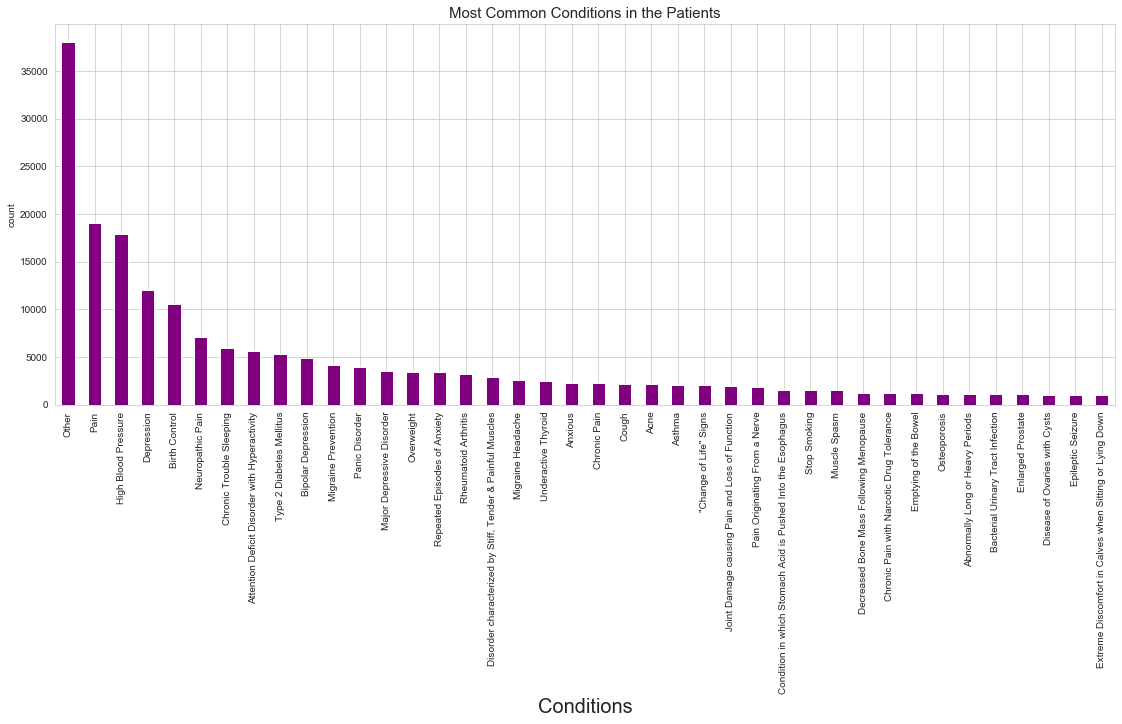

In [40]:
# checking the different types of conditions patients


df['Condition'].value_counts().head(40).plot.bar(figsize = (19, 7), color = 'purple')
plt.title('Most Common Conditions in the Patients', fontsize = 15)
plt.xlabel('Conditions', fontsize = 20)
plt.ylabel('count')
plt.show()

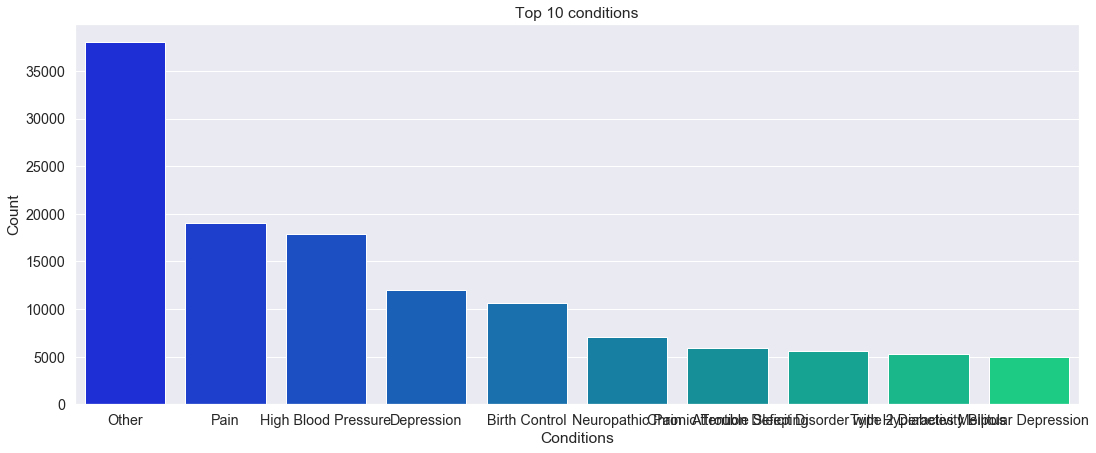

In [41]:
# This barplot show the top 10 conditions the people are suffering.
cond = dict(df['Condition'].value_counts())
top_condition = list(cond.keys())[0:10]
values = list(cond.values())[0:10]
sns.set(style = 'darkgrid', font_scale = 1.3)
plt.rcParams['figure.figsize'] = [18, 7]

sns_ = sns.barplot(x = top_condition, y = values, palette = 'winter')
sns_.set_title("Top 10 conditions")
sns_.set_xlabel("Conditions")
sns_.set_ylabel("Count");

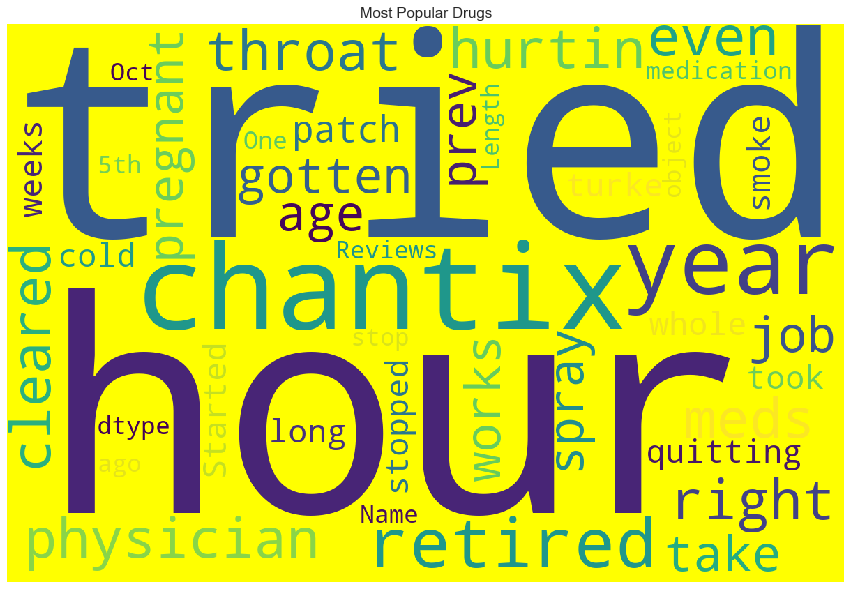

In [44]:
# Word clouds for reviews:

# let's see the words cloud for the reviews 

# most popular drugs


wordcloud = WordCloud(background_color = 'yellow', stopwords = stopwords, width = 1200, height = 800).generate(str(df['Reviews']))

plt.rcParams['figure.figsize'] = (15, 15)
plt.title('Most Popular Drugs', fontsize = 15)
print(wordcloud)
plt.axis('off')
plt.imshow(wordcloud)
plt.show()

In [45]:
data = [[col, df[col].nunique()] for col in df.columns.difference(["Reviews"])]
uniques = pd.DataFrame(data=data, columns=["columns", "num of unique values"])

bars = (alt.Chart()
           .mark_bar(size=25, 
                     color="#FFAA00",
                     strokeWidth=1,
                     stroke="white",
                     strokeOpacity=0.7)
           .encode(x=alt.X(shorthand="num of unique values:Q",
                           scale=alt.Scale(type="log"),
                           axis=alt.Axis(title="num of unique values, log scaled")),
                   y=alt.Y("columns:O", sort="-x"),
                   tooltip=("num of unique values:Q",
                            "columns:O",),
                   color=alt.Color("num of unique values",
                                   scale=alt.Scale(scheme="lightgreyteal",
                                                   type="log")))
           .properties(title='Unique Values'))

text = (alt.Chart()
           .mark_text(align="left",
                      baseline="middle",
                      dx=3)
           .encode(x=alt.X(shorthand="num of unique values:Q"),
                   y=alt.Y("columns:O",
                           axis=alt.Axis(title="columns",
                                         grid=False),
                           sort="-x"),
                   text="num of unique values:Q"))

chart = ((alt.layer(bars, text, data=uniques)
             .configure(background='#11043a')
             .configure_title(font="Arial",
                              fontSize=18,
                              color="#e6f3ff",
                              dy=-10)
             .configure_text(color="white")
             .configure_legend(titleFontSize=12,
                               titleColor="white",
                               tickCount=10,
                               titleOpacity=0.8,
                               labelColor="white",
                               labelOpacity=0.7,
                               titlePadding=10)
             .configure_axis(titleFontSize=13,
                             titlePadding=20,
                             titleColor="white",
                             titleOpacity=0.8,
                             labelColor="white",
                             labelOpacity=0.7,
                             labelFontSize=11,
                             tickOffset=0,
                             grid=True,
                             gridOpacity=0.15)
             .configure_view(strokeWidth=0)
             .properties(height=200, width=680)))

chart

alt.LayerChart(...)

In [46]:
data = (df.groupby(["Age", "Satisfaction"])
          .agg({"Reviews": "count"})
          .reset_index()).sort_values(["Age", "Satisfaction"], ascending=True)
#data['Cumulative_Reviews'] = data.groupby(['Age'])['Reviews'].apply(lambda x: x.cumsum())

bars = (alt.Chart(data=data, title="Distribution of Reviews Over Age")
           .mark_bar(size=40,
                     strokeWidth=0.5,
                     stroke="white")
           .encode(x=alt.X('Age:O',
                           axis=alt.Axis(title="Age groups", grid=False)),
                   y=alt.Y('Reviews:Q', stack='zero',
                           scale=alt.Scale(type="linear"),
                           axis=alt.Axis(title="num of reviews")),
                   order=alt.Order('Satisfaction', sort='ascending'),
                   color=alt.Color("Satisfaction:Q",
                                   scale=alt.Scale(scheme="lightgreyteal",
                                                   bins=[0,1,2,3],
                                                   reverse=False))))

text = (alt.Chart(data=data[data["Reviews"] > 1500])
           .mark_text(align="center",
                      baseline="middle",
                      dx=0, dy=5)
           .encode(x=alt.X("Age:O"),
                   y=alt.Y("Reviews:Q", stack='zero'),
                   size = alt.SizeValue(9),
                   text="Reviews:Q",
                   color=alt.condition(alt.datum.Satisfaction > 1,
                                          alt.value("white"),
                                          alt.value("black"))))
    
chart = (alt.layer(bars, text)
            .configure(background="#11043a")
            .configure_title(font="Arial",
                             fontSize=18,
                             color="#e6f3ff",
                             dy=-10)
            .configure_text(color="white")
            .configure_legend(titleFontSize=12,
                              titleColor="white",
                              tickCount=10,
                              titleOpacity=0.8,
                              labelColor="white",
                              labelOpacity=0.7,
                              titlePadding=10)
            .configure_axis(titleFontSize=13,
                            titlePadding=20,
                            titleColor="white",
                            titleOpacity=0.8,
                            labelColor="white",
                            labelOpacity=0.7,
                            labelAngle=0,
                            tickOffset=0,
                            grid=True,
                            gridOpacity=0.15)
            .configure_view(strokeWidth=0)
            .properties(height=300, width=700)
)
chart

alt.LayerChart(...)

In [104]:
df

,Age,Condition,Date,Drug,DrugId,EaseofUse,Effectiveness,Reviews,Satisfaction,Sex,Sides,UsefulCount
0,75 or over,Stuffy Nose,9/21/2014,25dph-7.5peh,146724,2,2,I'm a retired physician and of all the meds I ...,2,Male,"Drowsiness, dizziness , dry mouth /nose/thro...",0
1,25-34,Cold Symptoms,1/13/2011,25dph-7.5peh,146724,2,2,cleared me right up even with my throat hurtin...,2,Female,"Drowsiness, dizziness , dry mouth /nose/thro...",1
6,25-34,Birth Control,6/15/2017,wymzya fe,163180,2,2,Haven't gotten pregnant so it does it's job. I...,0,Female,"Nausea , vomiting , headache , bloating , ...",0
7,45-54,Disease of Ovaries with Cysts,1/30/2017,wymzya fe,163180,2,2,I have take this for 5 years age 45-50 to prev...,2,Female,"Nausea , vomiting , headache , bloating , ...",0
9,55-64,Stuffy Nose,10/29/2012,"12 hour nasal relief spray, non-aerosol",9800,2,0,The 12 hour spray only works for me for 6 hours.,0,Male,"Temporary burning, stinging, dryness in the no...",0
...,...,...,...,...,...,...,...,...,...,...,...,...
362799,25-34,Stop Smoking,11/16/2008,chantix,144470,0,2,I have tried the patch and quitting cold turke...,2,Female,"Nausea , headache , vomiting , drowsiness, g...",5
362801,55-64,Stop Smoking,11/14/2008,chantix,144470,2,2,I took the whole 12 weeks.I could have stopped...,2,Female,"Nausea , headache , vomiting , drowsiness, g...",2
362803,25-34,Stop Smoking,11/13/2008,chantix,144470,0,2,"As long as I was on chantix, I didn't smoke. ...",0,Female,"Nausea , headache , vomiting , drowsiness, g...",3
362804,55-64,Stop Smoking,11/13/2008,chantix,144470,2,2,Started this medication Oct 5th 2008. Haven't ...,2,Male,"Nausea , headache , vomiting , drowsiness, g...",1


In [105]:
cols = ['Reviews','Satisfaction','Effectiveness','EaseofUse']
satisfaction_model = df[cols]

In [106]:
satisfaction_model

,Reviews,Satisfaction,Effectiveness,EaseofUse
0,I'm a retired physician and of all the meds I ...,2,2,2
1,cleared me right up even with my throat hurtin...,2,2,2
6,Haven't gotten pregnant so it does it's job. I...,0,2,2
7,I have take this for 5 years age 45-50 to prev...,2,2,2
9,The 12 hour spray only works for me for 6 hours.,0,0,2
...,...,...,...,...
362799,I have tried the patch and quitting cold turke...,2,2,0
362801,I took the whole 12 weeks.I could have stopped...,2,2,2
362803,"As long as I was on chantix, I didn't smoke. ...",0,2,0
362804,Started this medication Oct 5th 2008. Haven't ...,2,2,2


In [107]:
reviews =satisfaction_model.copy()
reviews.reset_index(inplace=True)

In [108]:
reviews['Reviews'][6]

"LYZA BIRTH CONTROL\nThese are the WORST birth control pills I have ever taken!  I've only been taking them for a couple of weeks and I feel like a crazy person.  I've been crying, (for no reason), been super depressed, my anxiety is terrible, along with daily headaches and break outs.   I realize everyone's body reacts differently to medication,  but I've read nothing but negative reviews.  I can surely attest to that.  I wouldn't advise anyone to take these.   Absolutely awful.\n"

In [109]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re
ps = PorterStemmer()
corpus = []
for i in range(0, len(reviews)):
    review = re.sub('[^a-zA-Z]', ' ', reviews['Reviews'][i])
    review = review.lower()
    review = review.split()
    
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]
    review = ' '.join(review)
    corpus.append(review)

In [110]:
corpus[3]

'take year age prevent ovarian cyst burst stop age side effect'

In [127]:
len(corpus)

280127

In [112]:
## TFidf Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_v=TfidfVectorizer(max_features=5000,ngram_range=(1,3))
X=tfidf_v.fit_transform(corpus).toarray()

In [113]:
#Satisfaction

In [114]:
y=reviews['Satisfaction']

In [115]:
## Divide the dataset into Train and Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

In [116]:
tfidf_v.get_feature_names()[:20]

['abdomen',
 'abdomin',
 'abdomin cramp',
 'abdomin pain',
 'abil',
 'abilifi',
 'abl',
 'abl function',
 'abl get',
 'abl go',
 'abl sleep',
 'abl take',
 'abl walk',
 'abl work',
 'ablat',
 'abnorm',
 'absolut',
 'absolut noth',
 'absorb',
 'abus']

In [117]:
tfidf_v.get_params()

{'analyzer': 'word',
 'binary': False,
 'decode_error': 'strict',
 'dtype': numpy.float64,
 'encoding': 'utf-8',
 'input': 'content',
 'lowercase': True,
 'max_df': 1.0,
 'max_features': 5000,
 'min_df': 1,
 'ngram_range': (1, 3),
 'norm': 'l2',
 'preprocessor': None,
 'smooth_idf': True,
 'stop_words': None,
 'strip_accents': None,
 'sublinear_tf': False,
 'token_pattern': '(?u)\\b\\w\\w+\\b',
 'tokenizer': None,
 'use_idf': True,
 'vocabulary': None}

In [118]:
count_df = pd.DataFrame(X_train, columns=tfidf_v.get_feature_names())

In [119]:
count_df.head()

,abdomen,abdomin,abdomin cramp,abdomin pain,abil,abilifi,abl,abl function,abl get,abl go,...,yr ago,yr old,zap,zero,zoloft,zolpidem,zombi,zone,zyprexa,zyrtec
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [120]:
import matplotlib.pyplot as plt

In [121]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    See full source and example: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    thresh = cm.max() / 3.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [122]:
# Naive Bayes:

In [123]:
from sklearn.naive_bayes import MultinomialNB
classifier=MultinomialNB()

In [124]:
from sklearn import metrics
import numpy as np
import itertools

accuracy:   0.675
Confusion matrix, without normalization


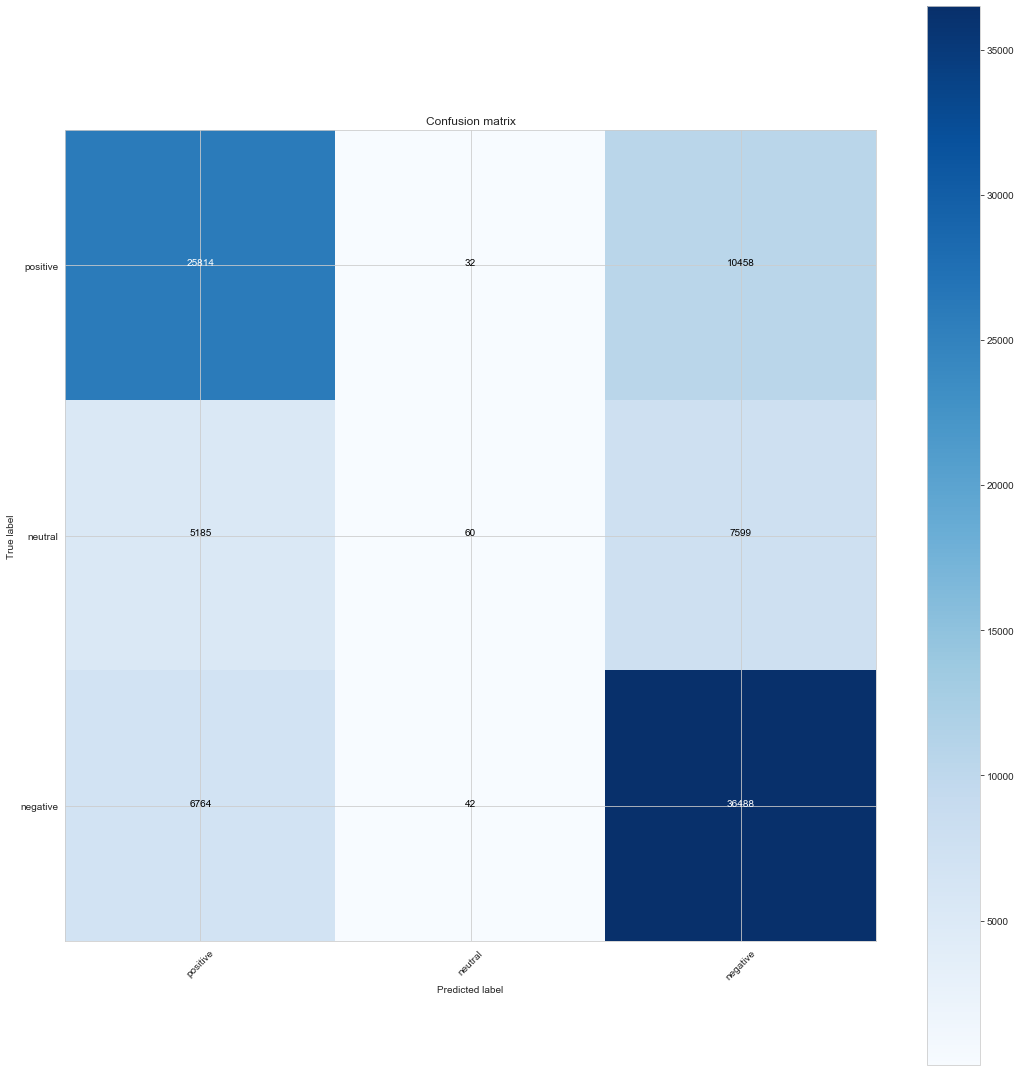

In [125]:
classifier.fit(X_train, y_train)
pred = classifier.predict(X_test)
score = metrics.accuracy_score(y_test, pred)
print("accuracy:   %0.3f" % score)
cm = metrics.confusion_matrix(y_test, pred)
plot_confusion_matrix(cm, classes=['positive', 'neutral','negative'])